## 1. Libraries & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score

## 2. Dataset Importation

In [2]:
# %%
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"

df = pd.read_csv(url)

## 3. Data cleaning & Data Quality 

### 3.1. Initial Checking

In [3]:
# Target analsyis:
# - There is no null values
# - There is no change in the definition during the time
# - 37.04 % of canceling

target = "is_canceled"

summary = df[target].value_counts().to_frame("Total")
summary["%"] = df[target].value_counts(normalize=True).round(4)
summary

,Total,%
is_canceled,,
0,75166,0.6296
1,44224,0.3704


In [4]:
df.head(2).T

,0,1
hotel,Resort Hotel,Resort Hotel
is_canceled,0,0
lead_time,342,737
arrival_date_year,2015,2015
arrival_date_month,July,July
arrival_date_week_number,27,27
arrival_date_day_of_month,1,1
stays_in_weekend_nights,0,0
stays_in_week_nights,0,0
adults,2,2


In [5]:
# Checking types of columns:
# - agent and company -> must be categorical columns
# - reservation_status_date -> must be date type

df["agent"] = df["agent"].astype("string")
df["company"] = df["company"].astype("string")

df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

df.dtypes

hotel                                     object
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                        object
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                      object
country                                   object
market_segment                            object
distribution_channel                      object
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                        object
assigned_room_type  

In [6]:
# Standarizing dataset
# - Columns and categorical columns with string normalization

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

df = df.drop("reservation_status", axis=1)
df = df.drop("reservation_status_date", axis=1)

categorical_columns = list(df.dtypes[df.dtypes == "object"].index)
numerical_columns = list(df.dtypes[df.dtypes != "object"].index)

for col in categorical_columns:
    df[col] = df[col].str.lower().str.strip().str.replace(" ", "_")

### 3.2. Duplicated values

In [7]:
df.duplicated().sum()

np.int64(32252)

In [8]:

print(f"Cancelation ratio [DF Original] = {df["is_canceled"].mean():.4f}")
print(f"Cancelation ratio [DF no Duplicates] = {df[~df.duplicated()]["is_canceled"].mean():.4f}")
print(f"Cancelation ratio [DF only Duplicates] = {df[df.duplicated()]["is_canceled"].mean():.4f}")

Cancelation ratio [DF Original] = 0.3704
Cancelation ratio [DF no Duplicates] = 0.2728
Cancelation ratio [DF only Duplicates] = 0.6343


In [9]:
dup_flag = df.duplicated(keep="first")

for col in ["market_segment", "customer_type", "deposit_type"]:
    print(f"===== {col} =====")
    print(pd.crosstab(dup_flag, df[col], normalize="index").round(3).T)
    print()

===== market_segment =====
row_0           False  True 
market_segment              
aviation        0.003  0.000
complementary   0.008  0.001
corporate       0.048  0.034
direct          0.135  0.025
groups          0.056  0.463
offline_ta/to   0.159  0.322
online_ta       0.591  0.154
undefined       0.000  0.000

===== customer_type =====
row_0            False  True 
customer_type                
contract         0.036  0.029
group            0.006  0.001
transient        0.825  0.551
transient-party  0.133  0.419

===== deposit_type =====
row_0         False  True 
deposit_type              
no_deposit    0.987  0.578
non_refund    0.012  0.421
refundable    0.001  0.002



### 3.3. NULL values

In [10]:
# Checking null values
# - children: 4
# - country: 488
# - agent: 16.340
# - company: 112.593

nulls = pd.DataFrame({
    "Nulls": df.isnull().sum(),
    "% of total": df.isnull().sum() / len(df) * 100
})
nulls["% of total"] = nulls["% of total"].round(3)

nulls[nulls["% of total"] > 0].sort_values(by="% of total", ascending=False)


,Nulls,% of total
company,112593,94.307
agent,16340,13.686
country,488,0.409
children,4,0.003


In [11]:
null_col = ["children", "country", "agent", "company"]

for col in null_col:
    print(f"Coluna: {col} | Unique values = {df[col].nunique()}")
    df_temp = df[col].value_counts(dropna=False).head(5).to_frame("Total")
    df_temp["%"] = (df[col].value_counts(normalize=True, dropna=False).head(5)).round(4)
    display(df_temp)
    print()

Coluna: children | Unique values = 5


,Total,%
children,,
0.0,110796,0.9280
1.0,4861,0.0407
2.0,3652,0.0306
3.0,76,0.0006
NaN,4,0.0000



Coluna: country | Unique values = 177


,Total,%
country,,
prt,48590,0.4070
gbr,12129,0.1016
fra,10415,0.0872
esp,8568,0.0718
deu,7287,0.0610



Coluna: agent | Unique values = 333


,Total,%
agent,,
9.0,31961,0.2677
<NA>,16340,0.1369
240.0,13922,0.1166
1.0,7191,0.0602
14.0,3640,0.0305



Coluna: company | Unique values = 352


,Total,%
company,,
<NA>,112593,0.9431
40.0,927,0.0078
223.0,784,0.0066
67.0,267,0.0022
45.0,250,0.0021


In [12]:
# - children: 4 -> Input of mode, it is very low percentual (4/119.000) ~0.003%
# - country: 488 -> Input "unknown", it is a information.
# - agent: 16.340 -> Input "no_agency", it is a information.
# - company: 112.593 -> Input "no_company", it is a information.

mode = df["children"].mode()[0]

df["children"] = df["children"].fillna(mode)
df["country"] = df["country"].fillna("unknown")
df["agent"] = df["agent"].fillna("no_agency")
df["company"] = df["company"].fillna("no_company")

df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

### 3.4. Outliers

In [13]:
# Outliers and wrong informations

df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119390.0,0.103886,0.398555,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [14]:
# display(df[df["adr"] < 0])
# display(df[df["adr"] > 500])
# display(df[df["adults"] > 5])
# display(df[df["adults"] <= 0])
# display(df[df["adults"] + df["children"] + df["babies"] <= 0])

print(f"Condition = ADR less than 0         | Total of events = {len(df[df["adr"] < 0]):<3} | Cancelation Ratio = {df[df["adr"] < 0]["is_canceled"].mean():.4f}")
print(f"Condition = ADR more then 500       | Total of events = {len(df[df["adr"] > 500]):<3} | Cancelation Ratio = {df[df["adr"] > 500]["is_canceled"].mean():.4f}")
print(f"Condition = Adults in booking > 5  | Total of events = {len(df[df["adults"] > 5]):<3} | Cancelation Ratio = {df[df["adults"] > 5]["is_canceled"].mean():.4f}")
print(f"Condition = Adults in booking = 0  | Total of events = {len(df[df["adults"] <= 0]):<3} | Cancelation Ratio = {df[df["adults"] <= 0]["is_canceled"].mean():.4f}")
print(f"Condition = People in booking = 0  | Total of events = {len(df[df["adults"] + df["children"] + df["babies"] <= 0]):<3} | Cancelation Ratio = {df[df["adults"] + df["children"] + df["babies"] <= 0]["is_canceled"].mean():.4f}")

Condition = ADR less than 0         | Total of events = 1   | Cancelation Ratio = 0.0000
Condition = ADR more then 500       | Total of events = 3   | Cancelation Ratio = 0.3333
Condition = Adults in booking > 5  | Total of events = 14  | Cancelation Ratio = 1.0000
Condition = Adults in booking = 0  | Total of events = 403 | Cancelation Ratio = 0.2705
Condition = People in booking = 0  | Total of events = 180 | Cancelation Ratio = 0.1389


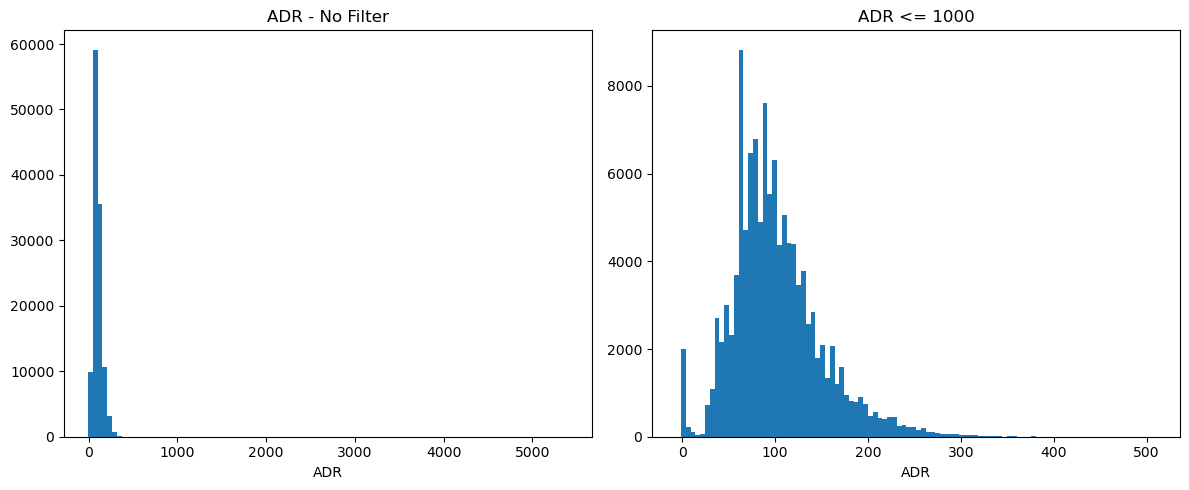

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["adr"], bins=100)
axes[0].set_title("ADR - No Filter")
axes[0].set_xlabel("ADR")

axes[1].hist(df[(df["adr"] <= 1000)]["adr"], bins=100)
axes[1].set_title("ADR <= 1000")
axes[1].set_xlabel("ADR")

plt.tight_layout()

plt.savefig("images/section_03_histogram_01_adr.jpeg")
plt.show()

In [16]:
# ADR Corrections

df["adr"] = df["adr"].abs()
df["adr"] = df["adr"].clip(upper=500)

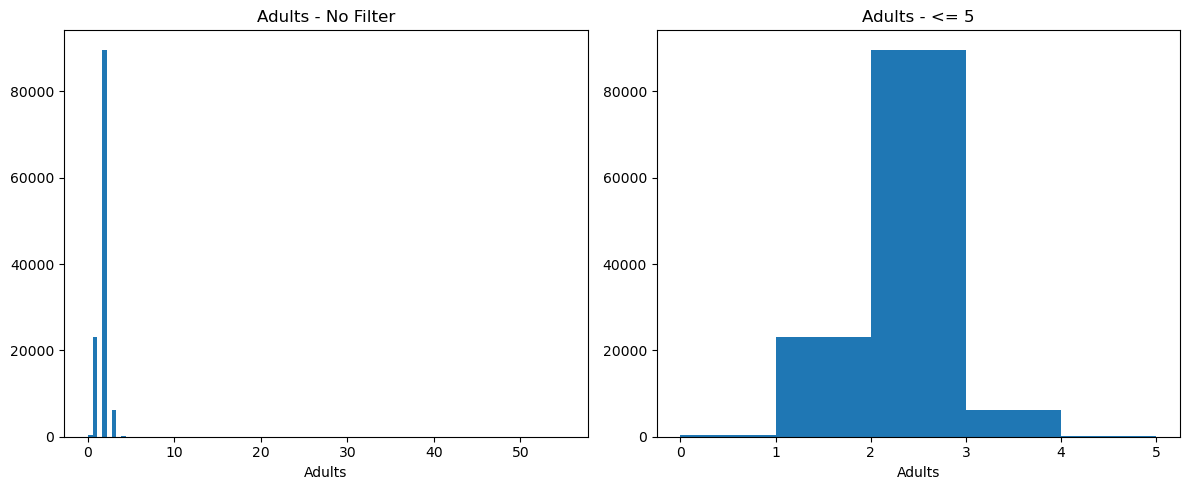

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["adults"], bins=100)
axes[0].set_title("Adults - No Filter")
axes[0].set_xlabel("Adults")

axes[1].hist(df[(df["adults"] <= 5)]["adults"], bins=5)
axes[1].set_title("Adults - <= 5")
axes[1].set_xlabel("Adults")

plt.tight_layout()

plt.savefig("images/section_03_histogram_02_adults.jpeg")
plt.show()

In [18]:
mask = df["adults"] > 5
df = df[~mask].reset_index(drop=True)

mask = df["adults"] == 0
df = df[~mask].reset_index(drop=True)

### 3.5. Target Check

C:\Users\bruno.lima\AppData\Local\Temp\ipykernel_20052\3807671324.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  date=pd.to_datetime(


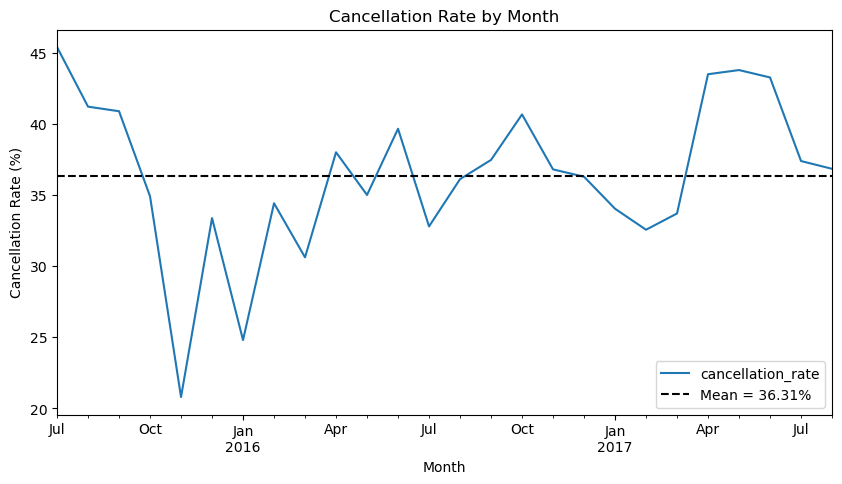

In [19]:
# Checking % cancelation by month:
# - There is some sazonality pherraps, but it is stable during the period
df_plot = (
    df.assign(
        date=pd.to_datetime(
            df["arrival_date_year"].astype(str) + "-" +
            df["arrival_date_month"] + "-01"
        )
    )
    .groupby("date")["is_canceled"]
    .mean()
    .mul(100)
    .reset_index(name="cancellation_rate")
)

df_plot.plot(
    x="date",
    y="cancellation_rate",
    figsize=(10, 5)
)

m = df_plot["cancellation_rate"].mean()
plt.axhline(
    m,
    linestyle="--",
    label=f"Mean = {m.round(2)}%",
    color="black"
)

plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Month")
plt.legend()

plt.savefig("images/section_03_histogram_03_cancellation_rate.jpeg")
plt.show()

## 4. Spliting dataset

In [20]:
df["arrival_date"] = pd.to_datetime(df["arrival_date_year"].astype(str) + "-" + df["arrival_date_month"] + "-" + df["arrival_date_day_of_month"].astype(str))
df["booking_date"] = (df["arrival_date"] - pd.to_timedelta(df["lead_time"], unit="D"))

C:\Users\bruno.lima\AppData\Local\Temp\ipykernel_20052\955333115.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["arrival_date"] = pd.to_datetime(df["arrival_date_year"].astype(str) + "-" + df["arrival_date_month"] + "-" + df["arrival_date_day_of_month"].astype(str))


In [21]:
df["booking_date"].min()

Timestamp('2013-06-24 00:00:00')

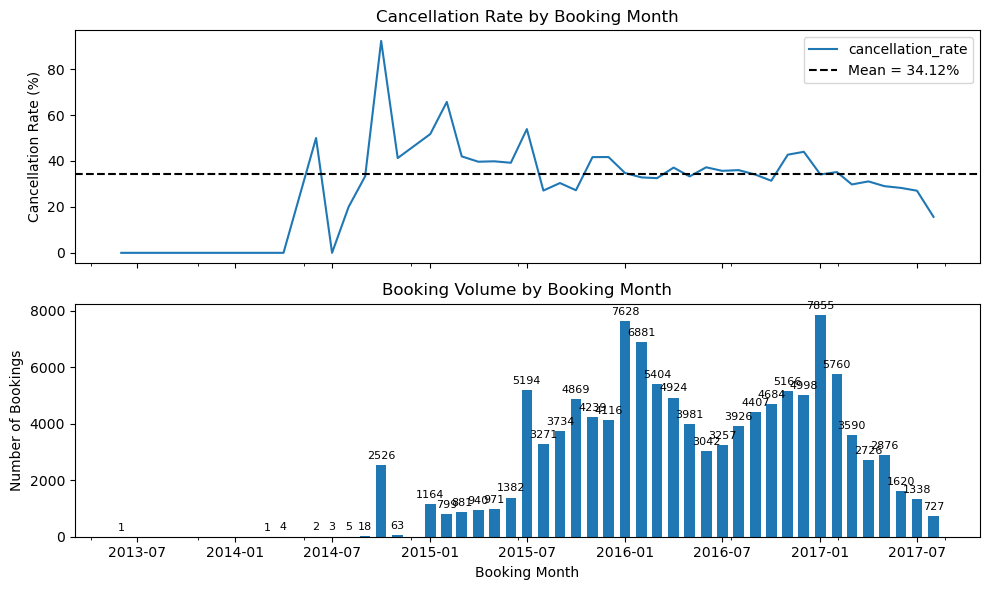

In [22]:
df_plot = (
    df.assign(
        date=df["booking_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("date")
    .agg(
        cancellation_rate=("is_canceled", "mean"),
        bookings=("is_canceled", "size")
    )
    .assign(cancellation_rate=lambda x: x["cancellation_rate"] * 100)
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

df_plot.plot(
    x="date",
    y="cancellation_rate",
    ax=axes[0],
    legend=False
)

m = df_plot["cancellation_rate"].mean()

axes[0].axhline(
    m,
    linestyle="--",
    color="black",
    label=f"Mean = {m.round(2)}%"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("Cancellation Rate (%)")
axes[0].set_title("Cancellation Rate by Booking Month")
axes[0].legend()

bars = axes[1].bar(
    df_plot["date"],
    df_plot["bookings"],
    width=20
)

axes[1].bar_label(
    bars,
    fmt="%d",
    padding=3,
    fontsize=8
)

axes[1].set_xlabel("Booking Month")
axes[1].set_ylabel("Number of Bookings")
axes[1].set_title("Booking Volume by Booking Month")

plt.tight_layout()

plt.savefig("images/section_03_graph_04_booking_date_cancellation_volume.jpeg", dpi=300, bbox_inches="tight")

plt.show()

In [23]:
mask = df["booking_date"] < "2015-01-01"

print(f"Lines to remove: {mask.sum()}")
print(f"Cancelation rate (removed lines): {df[mask]["is_canceled"].mean():.4f}")
print(f"Cancelation rate (remain lines): {df[~mask]["is_canceled"].mean():.4f}")

Lines to remove: 2623
Cancelation rate (removed lines): 0.9016
Cancelation rate (remain lines): 0.3587


In [24]:
last_arrival = df["arrival_date"].max()

df["bd_month"] = df["booking_date"].dt.to_period("M")

recent = (
    df[df["bd_month"] >= "2017-01"].groupby("bd_month")
                                   .agg(
                                       lead_time_max_observado=("lead_time", "max"),
                                       lead_time_mediana=("lead_time", "median"),
                                       taxa_cancelamento=("is_canceled", "mean"),
                                       volume=("is_canceled", "size")
                                       )
                                    .round(3)
    )

recent

,lead_time_max_observado,lead_time_mediana,taxa_cancelamento,volume
bd_month,,,,
2017-01,241,77.0,0.341,7855
2017-02,211,60.0,0.352,5760
2017-03,181,47.0,0.298,3590
2017-04,151,31.0,0.311,2726
2017-05,119,26.0,0.290,2876
2017-06,87,19.0,0.283,1620
2017-07,60,14.0,0.271,1338
2017-08,30,3.0,0.157,727


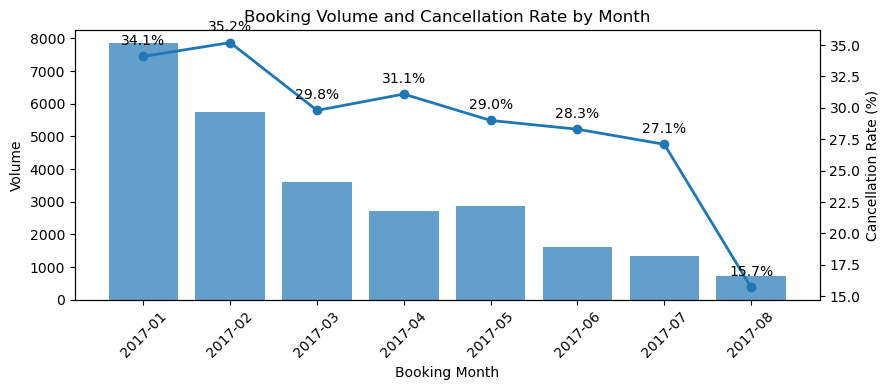

In [25]:
fig, ax1 = plt.subplots(figsize=(9, 4))

# Barras: volume
ax1.bar(
    recent.index.astype(str),
    recent["volume"],
    alpha=0.7,
    label="Volume"
)

ax1.set_xlabel("Booking Month")
ax1.set_ylabel("Volume")
ax1.tick_params(axis="x", rotation=45)

# Linha: taxa de cancelamento
ax2 = ax1.twinx()

ax2.plot(
    recent.index.astype(str),
    recent["taxa_cancelamento"] * 100,
    marker="o",
    linewidth=2,
    label="Cancellation Rate"
)

ax2.set_ylabel("Cancellation Rate (%)")

# Valores da taxa
for x, y in zip(range(len(recent)), recent["taxa_cancelamento"] * 100):
    ax2.annotate(
        f"{y:.1f}%",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )


plt.title("Booking Volume and Cancellation Rate by Month")
plt.tight_layout()

plt.savefig("images/section_03_graph_05_booking_date_cancellation_volume_right.jpeg", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
mask = df["booking_date"].between("2015-01-01", "2017-06-30")

df = df[mask].reset_index(drop=True)
print(f"Shape final = {df.shape}")

Shape final = (114285, 33)


In [27]:
last_arrival = df["arrival_date"].max()

df["bd_month"] = df["booking_date"].dt.to_period("M")

recent = (
    df.groupby("bd_month")
                        .agg(
                            taxa_cancelamento=("is_canceled", "mean"),
                            volume=("is_canceled", "size")
                            )
                        .round(3)
    )

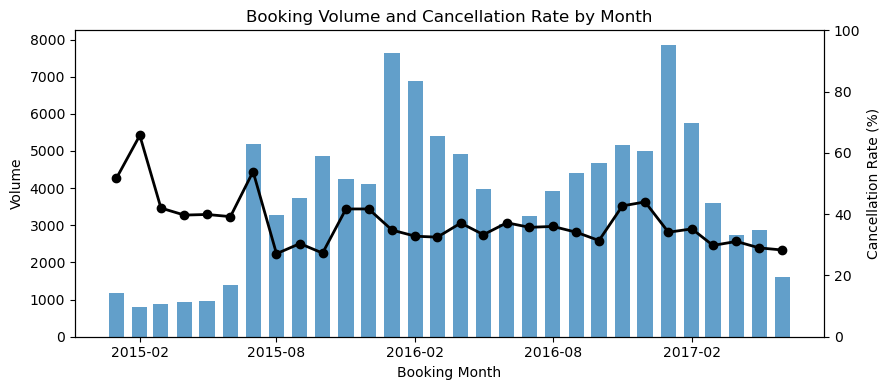

In [28]:
import matplotlib.dates as mdates

# Converter índice para datetime apenas para controlar o eixo X
x = recent.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(9, 4))

# Volume
bars = ax1.bar(
    x,
    recent["volume"],
    width=20,
    alpha=0.7
)

ax1.set_xlabel("Booking Month")
ax1.set_ylabel("Volume")

# Mostrar apenas a cada 6 meses
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.tick_params(axis="x")

# Taxa de cancelamento
ax2 = ax1.twinx()

ax2.plot(
    x,
    recent["taxa_cancelamento"] * 100,
    marker="o",
    linewidth=2,
    color="black"
)

ax2.set_ylabel("Cancellation Rate (%)")
ax2.set_ylim(0, 100)

plt.title("Booking Volume and Cancellation Rate by Month")
plt.tight_layout()

plt.savefig("images/section_03_graph_06_arrival_date_cancellation_final_volume.jpeg", dpi=300, bbox_inches="tight")

plt.show()

### 4.1 OOT

In [29]:
cutoff = "2017-01-01"
df_train = df[df["booking_date"] < cutoff].reset_index(drop=True)
df_test = df[df["booking_date"] >= cutoff].reset_index(drop=True)

print(f"Train = {df_train.shape} | {df_train["booking_date"].min().date()} -> {df_train["booking_date"].max().date()} | Cancelation Ratio = {df_train["is_canceled"].mean():.4f}")
print(f"Test  = {df_test.shape} | {df_test["booking_date"].min().date()} -> {df_test["booking_date"].max().date()} | Cancelation Ratio = {df_test["is_canceled"].mean():.4f}")
print()
print(f"Relative size Test dataset = {df_test.shape[0] / df.shape[0]:.4f}")

Train = (89858, 33) | 2015-01-01 -> 2016-12-31 | Cancelation Ratio = 0.3711
Test  = (24427, 33) | 2017-01-01 -> 2017-06-30 | Cancelation Ratio = 0.3241

Relative size Test dataset = 0.2137


In [30]:
df_train.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,arrival_date,booking_date,bd_month
0,resort_hotel,0,7,2015,july,27,1,0,1,1,...,no_agency,no_company,0,transient,75.0,0,0,2015-07-01,2015-06-24,2015-06
1,resort_hotel,0,13,2015,july,27,1,0,1,1,...,304.0,no_company,0,transient,75.0,0,0,2015-07-01,2015-06-18,2015-06
2,resort_hotel,0,14,2015,july,27,1,0,2,2,...,240.0,no_company,0,transient,98.0,0,1,2015-07-01,2015-06-17,2015-06
3,resort_hotel,0,14,2015,july,27,1,0,2,2,...,240.0,no_company,0,transient,98.0,0,1,2015-07-01,2015-06-17,2015-06
4,resort_hotel,0,0,2015,july,27,1,0,2,2,...,no_agency,no_company,0,transient,107.0,0,0,2015-07-01,2015-07-01,2015-07


### 4.2. TimeSeriesSplit x Train/Validation

In [31]:
df_train = df_train.sort_values(by="booking_date", ascending=True).reset_index(drop=True)

tscv = TimeSeriesSplit(n_splits=5)

In [32]:
for fold, (train_idx, val_idx) in enumerate(tscv.split(df_train)):
    print(f"Fold: {fold}")
    print(f"- train = {len(train_idx)}")
    print(f"{df_train.loc[train_idx, "booking_date"].min().date()} -> {df_train.loc[train_idx, "booking_date"].max().date()}")
    print(f"- validation = {len(val_idx)}")
    print(f"{df_train.loc[val_idx, "booking_date"].min().date()} -> {df_train.loc[val_idx, "booking_date"].max().date()}")

Fold: 0
- train = 14978
2015-01-01 -> 2015-09-03
- validation = 14976
2015-09-03 -> 2015-12-17
Fold: 1
- train = 29954
2015-01-01 -> 2015-12-17
- validation = 14976
2015-12-17 -> 2016-02-24
Fold: 2
- train = 44930
2015-01-01 -> 2016-02-24
- validation = 14976
2016-02-24 -> 2016-05-26
Fold: 3
- train = 59906
2015-01-01 -> 2016-05-26
- validation = 14976
2016-05-26 -> 2016-09-29
Fold: 4
- train = 74882
2015-01-01 -> 2016-09-29
- validation = 14976
2016-09-29 -> 2016-12-31


## 5. Exploratory Data Analysis (EDA)

In [33]:
target = "is_canceled"

y_train = df_train[target]
X_train = df_train.drop(columns=target)

y_test = df_test[target]
X_test = df_test.drop(columns=target)

In [34]:
numerical_columns = X_train.select_dtypes(include="number").columns.tolist()
categorical_columns = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

### 5.1. Univariate AUC & Information Value

In [35]:
resultados = []

for col in numerical_columns:
    valid = X_train[col].notna()
    auc = roc_auc_score(y_train[valid], X_train.loc[valid, col])
    forca = max(auc, 1-auc)
    resultados.append({
        "feature": col, 
        "auc_bruta": auc, 
        "forca": forca
        })

tabela_auc = pd.DataFrame(resultados).sort_values(by="forca", ascending=False).reset_index(drop=True)
tabela_auc

,feature,auc_bruta,forca
0,lead_time,0.677567,0.677567
1,total_of_special_requests,0.367938,0.632062
2,booking_changes,0.431872,0.568128
3,arrival_date_year,0.567504,0.567504
4,previous_cancellations,0.550443,0.550443
5,required_car_parking_spaces,0.450810,0.549190
6,adr,0.537155,0.537155
7,arrival_date_week_number,0.471575,0.528425
8,adults,0.523562,0.523562
9,days_in_waiting_list,0.523133,0.523133


In [36]:
def calculate_woe_iv(feature, target):
    df_temp = pd.DataFrame({"feature": feature, "target": target})

    agrupado = df_temp.groupby("feature")["target"].agg(
        eventos="sum",
        total="count"
    )
    agrupado["nao_eventos"] = agrupado["total"] - agrupado["eventos"]

    total_eventos = agrupado["eventos"].sum()
    total_nao_eventos = agrupado["nao_eventos"].sum()

    agrupado["pct_eventos"] = (agrupado["eventos"] + 0.5) / (total_eventos + 0.5)
    agrupado["pct_nao_eventos"] = (agrupado["nao_eventos"] + 0.5) / (total_nao_eventos + 0.5)

    agrupado["woe"] = np.log(agrupado["pct_eventos"] / agrupado["pct_nao_eventos"])
    agrupado["iv_parcial"] = (agrupado["pct_eventos"] - agrupado["pct_nao_eventos"]) * agrupado["woe"]

    iv_total = agrupado["iv_parcial"].sum()

    return agrupado, iv_total

In [37]:
resultados_iv = []
for col in categorical_columns:
    tabela_woe, iv = calculate_woe_iv(X_train[col], y_train)
    resultados_iv.append({
        "feature": col,
        "iv": iv,
        "n_categories": X_train[col].nunique()
    })

tabela_iv = pd.DataFrame(resultados_iv).sort_values(by="iv", ascending=False).reset_index(drop=True)
tabela_iv

,feature,iv,n_categories
0,deposit_type,2.041111,3
1,agent,0.788561,304
2,country,0.675002,166
3,market_segment,0.275557,8
4,assigned_room_type,0.230960,11
5,customer_type,0.182604,4
6,distribution_channel,0.130056,5
7,company,0.109466,303
8,hotel,0.077772,2
9,reserved_room_type,0.027520,9


### 5.1.1. Feature test selection

In [48]:
tabela_auc_padrao = tabela_auc.rename(columns={"forca": "power"})[["feature", "power"]]
tabela_auc_padrao["type"] = "numeric"

tabela_iv_padrao = tabela_iv.rename(columns={"iv": "power"})[["feature", "power"]]
tabela_iv_padrao["type"] = "categoric"

tabela_poder = pd.concat([tabela_auc_padrao, tabela_iv_padrao], ignore_index=True)
tabela_poder = tabela_poder.sort_values("power", ascending=False).reset_index(drop=True)

tabela_poder

,feature,power,type
0,deposit_type,2.041111,categoric
1,agent,0.788561,categoric
2,lead_time,0.677567,numeric
3,country,0.675002,categoric
4,total_of_special_requests,0.632062,numeric
5,booking_changes,0.568128,numeric
6,arrival_date_year,0.567504,numeric
7,previous_cancellations,0.550443,numeric
8,required_car_parking_spaces,0.549190,numeric
9,adr,0.537155,numeric


In [50]:
auc_power = 0.52
iv_power = 0.02

lista_features = tabela_poder[
    ((tabela_poder["type"] == "numeric") & (tabela_poder["power"] >= auc_power)) |
    ((tabela_poder["type"] == "categoric") & (tabela_poder["power"] >= iv_power))
]["feature"].tolist()

lista_features

['deposit_type',
 'agent',
 'lead_time',
 'country',
 'total_of_special_requests',
 'booking_changes',
 'arrival_date_year',
 'previous_cancellations',
 'required_car_parking_spaces',
 'adr',
 'arrival_date_week_number',
 'adults',
 'days_in_waiting_list',
 'stays_in_week_nights',
 'market_segment',
 'assigned_room_type',
 'customer_type',
 'distribution_channel',
 'company',
 'hotel',
 'reserved_room_type',
 'arrival_date_month']

In [38]:
# Checking deposit_type >> too high to be normal

pd.DataFrame({
    "quantity": y_train.groupby(X_train["deposit_type"]).size(),
    "cancellation_rate": y_train.groupby(X_train["deposit_type"]).mean().round(4)
})

,quantity,cancellation_rate
deposit_type,,
no_deposit,77985,0.2780
non_refund,11726,0.9928
refundable,147,0.1497


In [39]:
# Checking assigned_room_type x reserved_room_type

df.groupby(df["assigned_room_type"] == df["reserved_room_type"]).agg(
    cancellation_rate=("is_canceled", "mean"),
    quantity=("is_canceled", "size")
    )


,cancellation_rate,quantity
False,0.054119,14542
True,0.405773,99743


### 5.2. Decil Cut

,cancelation_rate,quantity
lead_time_decil,,
"(-0.001, 3.0]",0.086367,9668
"(3.0, 13.0]",0.173374,8473
"(13.0, 31.0]",0.292002,9202
"(31.0, 50.0]",0.355527,8621
"(50.0, 76.0]",0.388258,9164
"(76.0, 108.0]",0.427452,8808
"(108.0, 151.0]",0.426521,9268
"(151.0, 197.0]",0.471189,8712
"(197.0, 270.0]",0.498554,8988


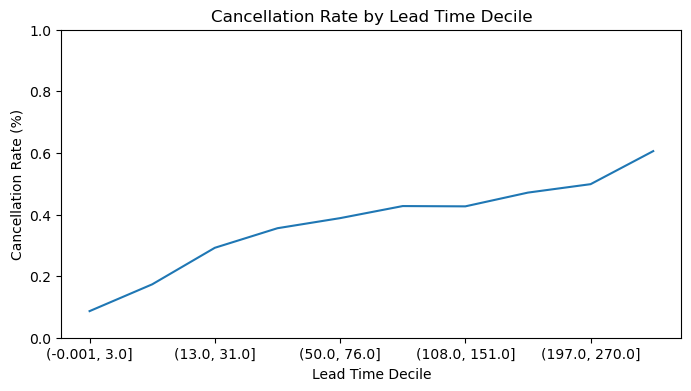

In [40]:
X_train["lead_time_decil"] = pd.qcut(X_train["lead_time"], q=10, duplicates="drop")

tabela_decil = pd.DataFrame({
    "lead_time_decil": X_train["lead_time_decil"],
    "is_canceled": y_train
}).groupby("lead_time_decil", observed=True)["is_canceled"].agg(
    cancelation_rate="mean",
    quantity="count"
)

display(tabela_decil)

ax = tabela_decil["cancelation_rate"].plot(kind="line",figsize=(8, 4))

plt.xlabel("Lead Time Decile")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Lead Time Decile")
plt.ylim(0,1)
plt.show()

,cancelation_rate,quantity
adr_decil,,
"(-0.001, 48.5]",0.221085,8992
"(48.5, 62.9]",0.409934,8999
"(62.9, 73.0]",0.318322,9104
"(73.0, 80.75]",0.432354,8951
"(80.75, 90.0]",0.393589,9764
"(90.0, 100.0]",0.382532,9343
"(100.0, 110.7]",0.422017,7803
"(110.7, 126.0]",0.367283,8974
"(126.0, 151.2]",0.404315,8946


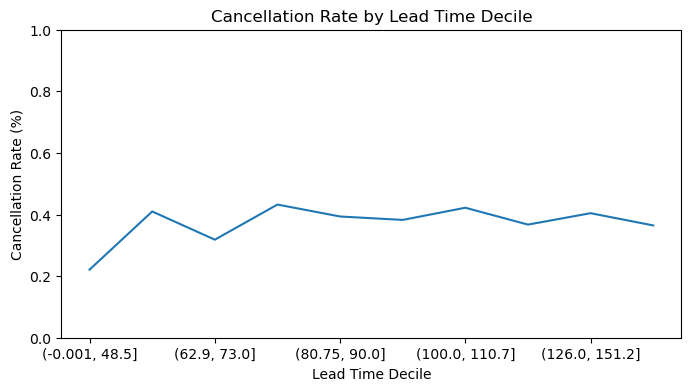

In [41]:
X_train["adr_decil"] = pd.qcut(X_train["adr"], q=10, duplicates="drop")

tabela_decil = pd.DataFrame({
    "adr_decil": X_train["adr_decil"],
    "is_canceled": y_train
}).groupby("adr_decil", observed=True)["is_canceled"].agg(
    cancelation_rate="mean",
    quantity="count"
)

display(tabela_decil)

ax = tabela_decil["cancelation_rate"].plot(kind="line",figsize=(8, 4))

plt.xlabel("Lead Time Decile")
plt.ylabel("Cancellation Rate (%)")
plt.title("Cancellation Rate by Lead Time Decile")
plt.ylim(0,1)
plt.show()

In [42]:
def taxa_por_valor(feature, target):
    tabela = pd.DataFrame({
        "feature": feature,
        "is_canceled": target
    }).groupby(by="feature")["is_canceled"].agg(
        cancelation_rate="mean",
        quantity="count"
    )
    return tabela

total_of_special_requests


,cancelation_rate,quantity
feature,,
0,0.474545,53900
1,0.211133,24397
2,0.232286,9639
3,0.207962,1683
4,0.115385,208
5,0.032258,31


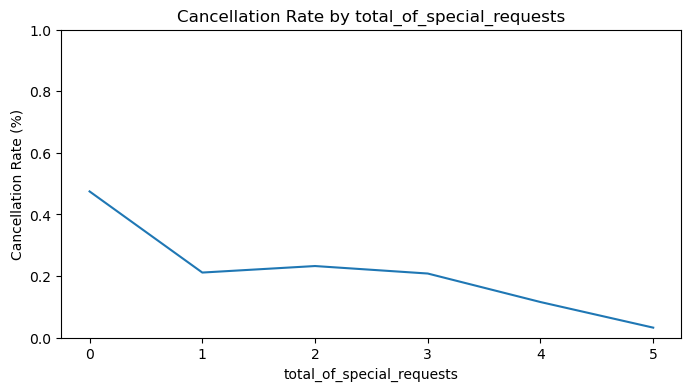


booking_changes


,cancelation_rate,quantity
feature,,
0,0.408756,76224
1,0.148927,9649
2,0.197806,2826
3,0.138848,677
4,0.192727,275
5,0.182796,93
6,0.277778,54
7,0.136364,22
8,0.363636,11


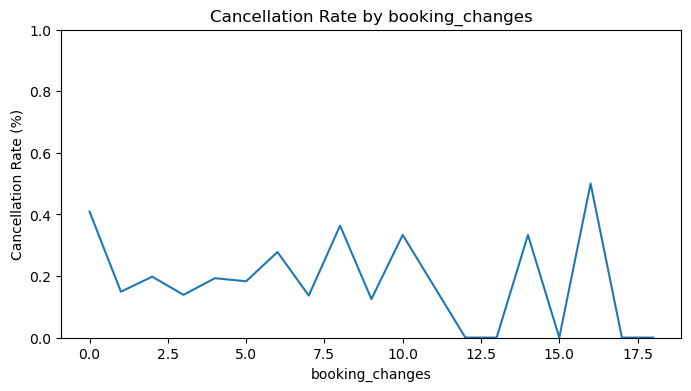


previous_cancellations


,cancelation_rate,quantity
feature,,
0,0.346406,85983
1,0.948965,3527
2,0.383562,73
3,0.300000,60
4,0.187500,16
5,0.153846,13
6,1.000000,7
11,0.285714,35
13,0.916667,12


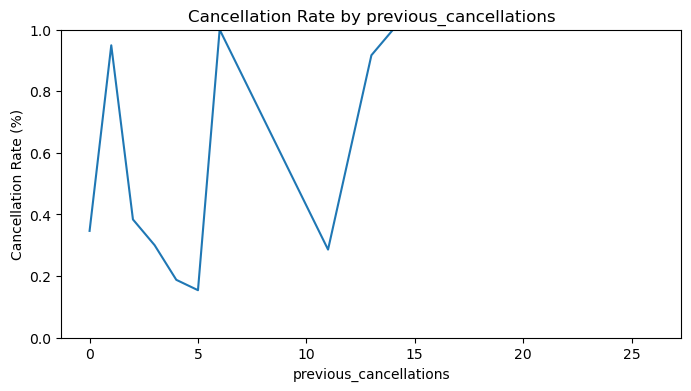


required_car_parking_spaces


,cancelation_rate,quantity
feature,,
0,0.395537,84298
1,0.000000,5539
2,0.000000,18
3,0.000000,2
8,0.000000,1


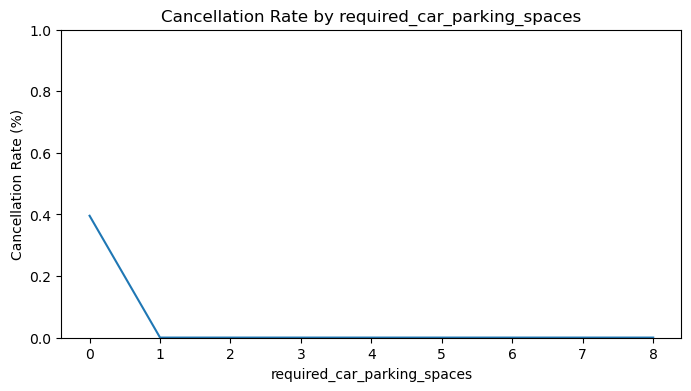

In [43]:
cut = ["total_of_special_requests", "booking_changes", "previous_cancellations", "required_car_parking_spaces"]

for col in cut:
    print(col)
    tabela = taxa_por_valor(X_train[col], y_train)
    display(tabela)

    ax = tabela["cancelation_rate"].plot(kind="line",figsize=(8, 4))

    plt.xlabel(f"{col}")
    plt.ylabel("Cancellation Rate (%)")
    plt.title(f"Cancellation Rate by {col}")
    plt.ylim(0,1)
    plt.show()
    print()

In [44]:
mask = X_train["previous_cancellations"] == 1

print(pd.crosstab(
    X_train.loc[mask, "deposit_type"],
    y_train[mask],
    normalize="index"
).round(4))

print()
print(X_train.loc[mask, "agent"].value_counts(normalize=True).head(10).round(4))

is_canceled        0       1
deposit_type                
no_deposit    0.1156  0.8844
non_refund    0.0000  1.0000

agent
no_agency    0.1358
1.0          0.1179
19.0         0.0964
9.0          0.0961
29.0         0.0513
37.0         0.0448
3.0          0.0388
240.0         0.036
96.0         0.0224
6.0          0.0221
Name: proportion, dtype: Float64


In [45]:
pd.crosstab(
    X_train["required_car_parking_spaces"] > 0,
    df_train["assigned_room_type"] == df_train["reserved_room_type"]
)

col_0,False,True
required_car_parking_spaces,,
False,10783,73515
True,1325,4235


In [46]:
mask = X_train["required_car_parking_spaces"] > 0

print(X_train.loc[mask, "market_segment"].value_counts(normalize=True).round(4))
print()
print(X_train.loc[mask, "distribution_channel"].value_counts(normalize=True).round(4))
print()
print(X_train.loc[mask, "customer_type"].value_counts(normalize=True).round(4))

market_segment
online_ta        0.5245
direct           0.2629
offline_ta/to    0.0827
corporate        0.0723
groups           0.0459
complementary    0.0106
aviation         0.0011
Name: proportion, dtype: float64

distribution_channel
ta/to        0.6236
direct       0.2878
corporate    0.0885
undefined    0.0002
Name: proportion, dtype: float64

customer_type
transient          0.8556
transient-party    0.1158
contract           0.0234
group              0.0052
Name: proportion, dtype: float64
